In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import os
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load your test datasets
X_test = np.load('/content/drive/MyDrive/PHYSIODATA/X_test.npy')
y_test = np.load('/content/drive/MyDrive/PHYSIODATA/y_test.npy')
X_train = np.load('/content/drive/MyDrive/PHYSIODATA/X_train.npy')
y_train = np.load('/content/drive/MyDrive/PHYSIODATA/y_train.npy')

In [6]:
# Encode the labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

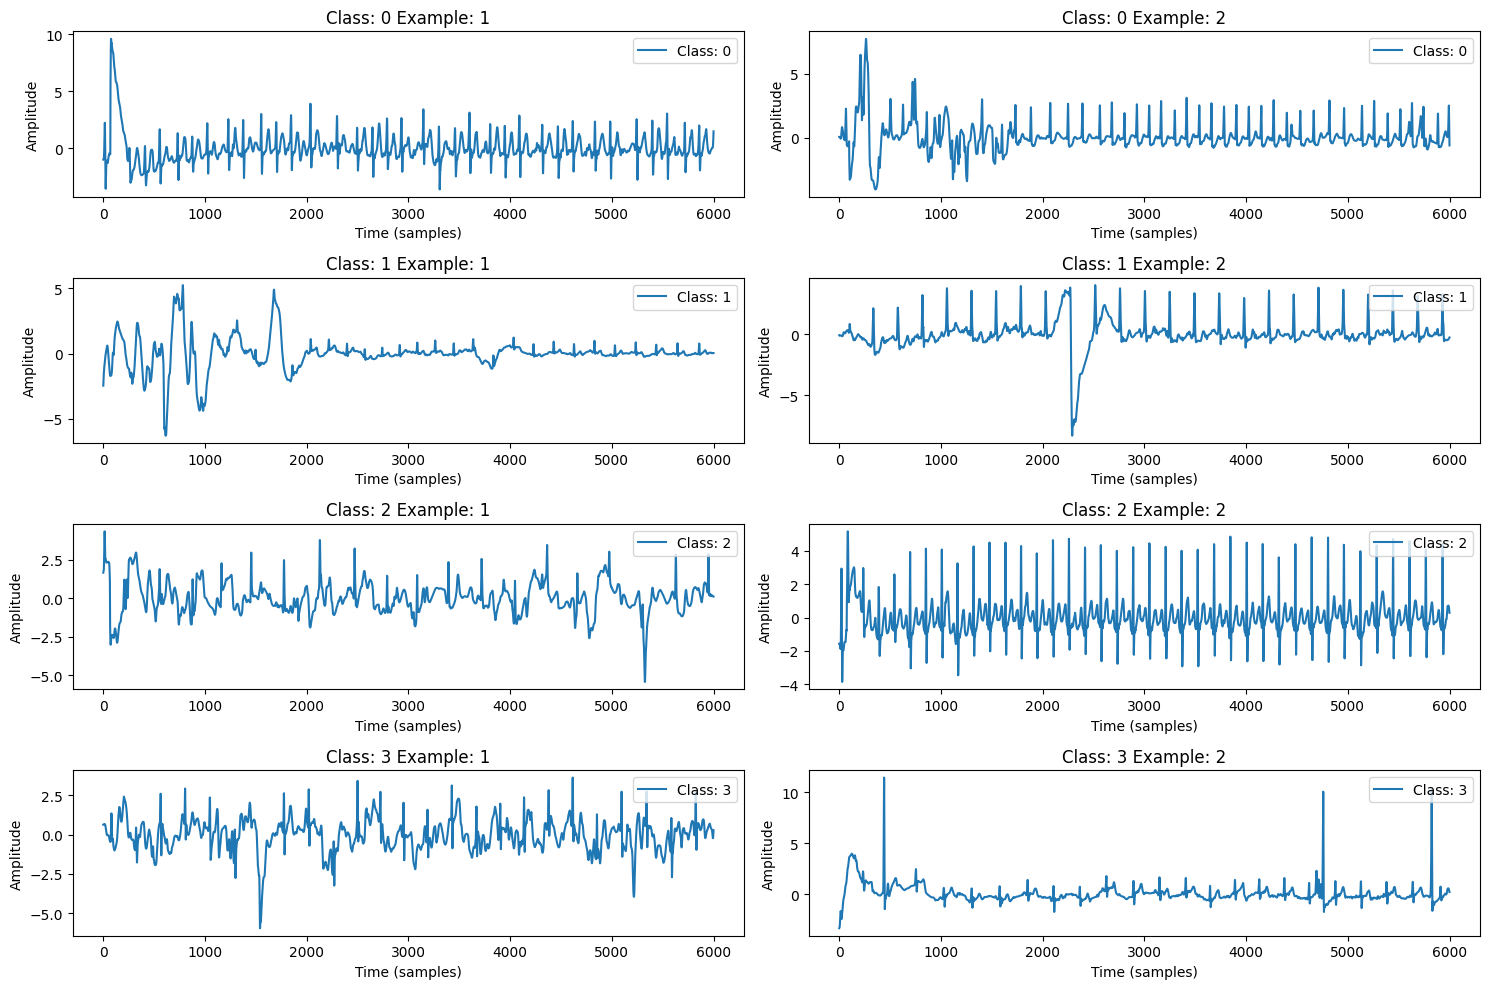

In [7]:
def plot_signal_per_class(X, y, label_encoder, num_examples=1):
    # Get unique classes
    unique_classes = np.unique(y)
    # Reverse mapping of labels to class names
    reverse_label_mapping = {index: label for index, label in enumerate(label_encoder.classes_)}

    plt.figure(figsize=(15, 10))
    for i, class_label in enumerate(unique_classes):
        indices = np.where(y == class_label)[0]
        for j in range(min(num_examples, len(indices))):
            index = indices[j]
            plt.subplot(len(unique_classes), num_examples, i * num_examples + j + 1)
            plt.plot(X[index].squeeze(), label=f'Class: {reverse_label_mapping[class_label]}')
            plt.legend(loc='upper right')
            plt.title(f'Class: {reverse_label_mapping[class_label]} Example: {j+1}')
            plt.xlabel('Time (samples)')
            plt.ylabel('Amplitude')
            plt.tight_layout()

    plt.show()

# Call the function to plot a signal from each class
plot_signal_per_class(X_train, y_train, label_encoder, num_examples=2)

In [8]:
# Reshape and resize to (150, 150, 1) 
height, width, channels = 150, 150, 1
def resize_and_reshape(data):
    resized_data = np.zeros((data.shape[0], height, width, channels))
    for i in range(data.shape[0]):
        image = np.reshape(data[i], (data.shape[1], 1, 1))
        image_resized = tf.image.resize(image, (height, width))
        resized_data[i] = image_resized.numpy()
    return resized_data

X_train_resized = resize_and_reshape(X_train)
X_test_resized = resize_and_reshape(X_test)

In [9]:
# Save the datasets
np.save('/content/drive/MyDrive/PHYSIODATA/X_train_resized.npy', X_train_resized)
np.save('/content/drive/MyDrive/PHYSIODATA/y_train_resized.npy', y_train)
np.save('/content/drive/MyDrive/PHYSIODATA/X_test_resized.npy', X_test_resized)
np.save('/content/drive/MyDrive/PHYSIODATA/y_test_resized.npy', y_test)

In [10]:
# Load the datasets
X_train_resized = np.load('/content/drive/MyDrive/PHYSIODATA/X_train_resized.npy')
X_test_resized = np.load('/content/drive/MyDrive/PHYSIODATA/X_test_resized.npy')
y_train = np.load('/content/drive/MyDrive/PHYSIODATA/y_train_resized.npy')
y_test = np.load('/content/drive/MyDrive/PHYSIODATA/y_test_resized.npy')

In [11]:
# Preprocess the data
X_train_resized = tf.keras.applications.vgg16.preprocess_input(np.repeat(X_train_resized, 3, axis=-1))
X_test_resized = tf.keras.applications.vgg16.preprocess_input(np.repeat(X_test_resized, 3, axis=-1))

In [21]:
# Define the VGG16 model
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(height, width, 3))
x = base_model_vgg.output
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)
model_vgg = Model(inputs=base_model_vgg.input, outputs=predictions)

# Freeze the base model layers
for layer in base_model_vgg.layers:
    layer.trainable = False

# Compile the model
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
checkpoint_path = '/content/drive/MyDrive/PHYSIO2D/PHYSIOvgg.h5'
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')

In [22]:
# Train and evaluate the model
history = model_vgg.fit(
    X_train_resized, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(X_test_resized, y_test),
    callbacks=[checkpoint]
)


train_accuracy = model_vgg.evaluate(X_train_resized, y_train, verbose=0)[1]
test_accuracy = model_vgg.evaluate(X_test_resized, y_test, verbose=0)[1]

print(f"Training Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

Epoch 1/300
139/140 [============================>.] - ETA: 0s - loss: 1.0848 - accuracy: 0.5534

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


140/140 [==============================] - 7s 43ms/step - loss: 1.0845 - accuracy: 0.5535 - val_loss: 0.9411 - val_accuracy: 0.5472
Epoch 2/300
140/140 [==============================] - 4s 27ms/step - loss: 0.9570 - accuracy: 0.5763 - val_loss: 0.9110 - val_accuracy: 0.5760
Epoch 3/300
140/140 [==============================] - 4s 27ms/step - loss: 0.9318 - accuracy: 0.5903 - val_loss: 0.8913 - val_accuracy: 0.5877
Epoch 4/300
140/140 [==============================] - 4s 28ms/step - loss: 0.9088 - accuracy: 0.5998 - val_loss: 0.8966 - val_accuracy: 0.5947
Epoch 5/300
140/140 [==============================] - 4s 26ms/step - loss: 0.9070 - accuracy: 0.5978 - val_loss: 0.8667 - val_accuracy: 0.6018
Epoch 6/300
140/140 [==============================] - 4s 25ms/step - loss: 0.8929 - accuracy: 0.6086 - val_loss: 0.8824 - val_accuracy: 0.6003
Epoch 7/300
140/140 [==============================] - 4s 27ms/step - loss: 0.8802 - accuracy: 0.6135 - val_loss: 0.8631 - val_accuracy: 0.6028
Epoc

In [23]:
# Train and evaluate the model
history = model_vgg.fit(
    X_train_resized, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(X_test_resized, y_test),
    callbacks=[checkpoint]
)


train_accuracy = model_vgg.evaluate(X_train_resized, y_train, verbose=0)[1]
test_accuracy = model_vgg.evaluate(X_test_resized, y_test, verbose=0)[1]

print(f"Training Accuracy: {train_accuracy}, Test Accuracy: {test_accuracy}")

Epoch 1/100
140/140 [==============================] - 5s 33ms/step - loss: 0.2176 - accuracy: 0.9222 - val_loss: 1.0205 - val_accuracy: 0.8873
Epoch 2/100
140/140 [==============================] - 4s 31ms/step - loss: 0.1281 - accuracy: 0.9488 - val_loss: 0.9687 - val_accuracy: 0.9131
Epoch 3/100
140/140 [==============================] - 4s 25ms/step - loss: 0.1118 - accuracy: 0.9546 - val_loss: 0.9721 - val_accuracy: 0.9111
Epoch 4/100
140/140 [==============================] - 4s 25ms/step - loss: 0.1192 - accuracy: 0.9540 - val_loss: 0.9982 - val_accuracy: 0.9030
Epoch 5/100
140/140 [==============================] - 4s 25ms/step - loss: 0.1070 - accuracy: 0.9581 - val_loss: 0.9890 - val_accuracy: 0.9040
Epoch 6/100
140/140 [==============================] - 4s 25ms/step - loss: 0.1201 - accuracy: 0.9511 - val_loss: 1.0606 - val_accuracy: 0.8843
Epoch 7/100
140/140 [==============================] - 4s 25ms/step - loss: 0.1080 - accuracy: 0.9587 - val_loss: 0.9866 - val_accuracy:

In [24]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/PHYSIO2D/PHYSIOvgg.h5'
loaded_model = load_model(model_path)

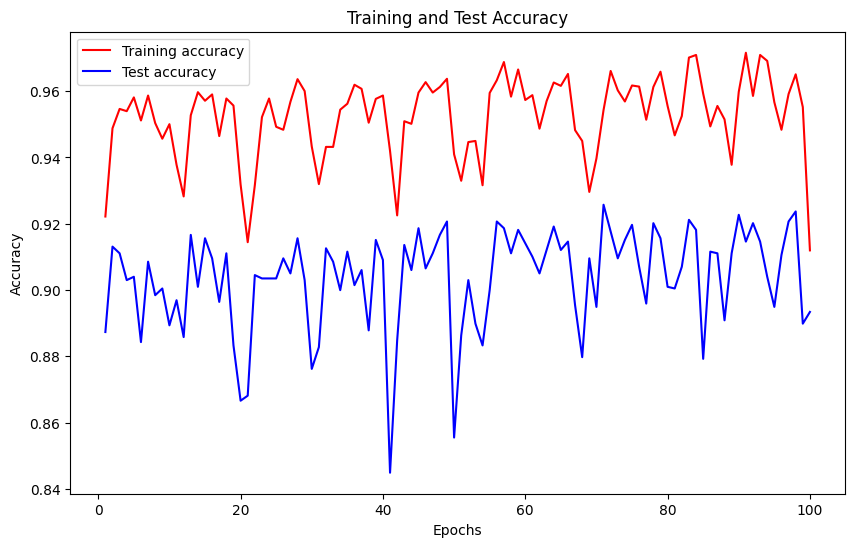

In [25]:
# Plot training and validation accuracies over epochs
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)  # Number of epochs

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'r', label='Training accuracy')  # 'bo' gives blue color and dot markers
plt.plot(epochs, val_acc, 'b', label='Test accuracy')   # 'b' gives solid blue line
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# Generate predictions
y_pred = loaded_model.predict(X_test_resized)
y_pred_classes = np.argmax(y_pred, axis=1)

62/62 [==============================] - 1s 11ms/step


In [28]:
# Print classification report
class_report = classification_report(y_test, y_pred_classes)
print("\nClassification Report:\n", class_report)


Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       185
           1       0.94      0.95      0.94      1137
           2       0.91      0.89      0.90       627
           3       0.88      0.93      0.90        30

    accuracy                           0.93      1979
   macro avg       0.91      0.92      0.91      1979
weighted avg       0.93      0.93      0.93      1979



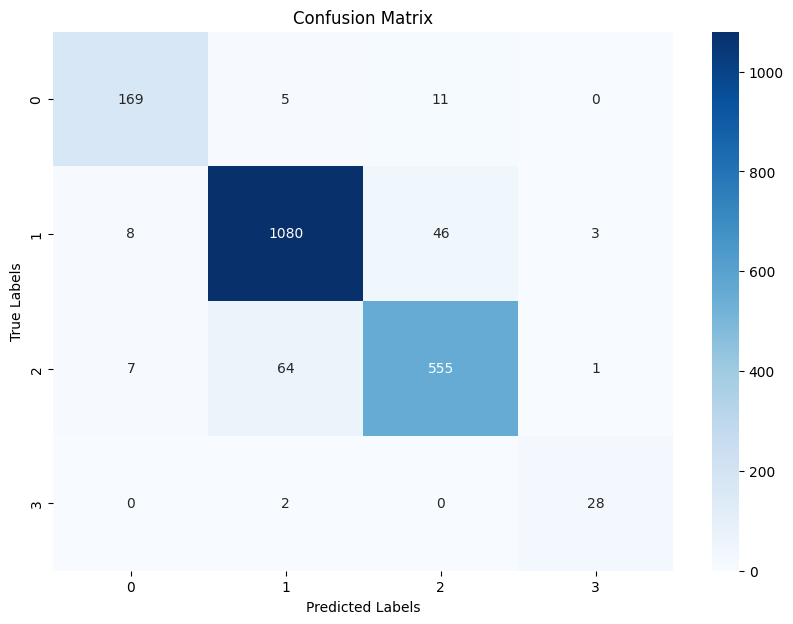

In [29]:
# Compute and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

62/62 [==============================] - 1s 11ms/step


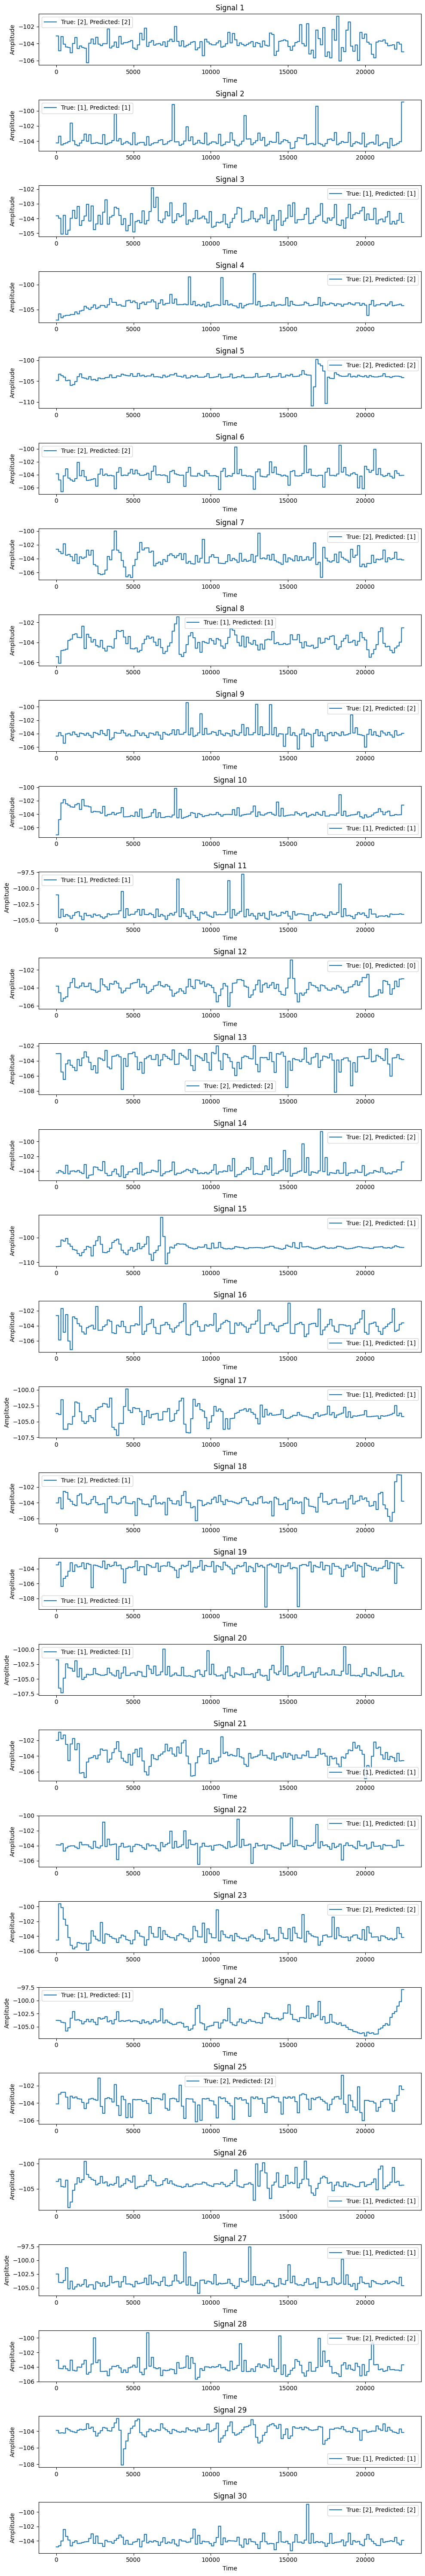

Correct Predictions: 1832
Incorrect Predictions: 147


In [31]:
# Plot sample signals with true and predicted labels, and display prediction accuracy
def plot_and_predict(X_test, y_test, model, num_samples=10, channel=0):

    # Ensure num_samples does not exceed length of X_test
    num_samples = min(num_samples, len(X_test))

    # Predict the labels
    predictions = model.predict(X_test)
    predicted_labels = np.argmax(predictions, axis=1)

    # Count correct and incorrect predictions
    correct = np.sum(predicted_labels == y_test)
    incorrect = len(y_test) - correct



    # Start plotting
    fig, axes = plt.subplots(num_samples, 1, figsize=(10, num_samples * 2))
    if num_samples == 1:
        axes = [axes]  # Make it iterable

    for i, ax in enumerate(axes):
        signal = X_test[i, :, :, channel].flatten()  # Flatten to 1D for plotting
        true_label = [y_test[i]]
        predicted_label = [predicted_labels[i]]
        ax.plot(signal, label=f'True: {true_label}, Predicted: {predicted_label}')
        ax.legend()
        ax.set_title(f'Signal {i+1}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Amplitude')

    plt.tight_layout()
    plt.show()

    print(f"Correct Predictions: {correct}")
    print(f"Incorrect Predictions: {incorrect}")


plot_and_predict(X_test_resized, y_test, loaded_model, num_samples=30)